In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import glob
import os
from matplotlib.ticker import ScalarFormatter

In [2]:
model_outputs = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/2025/manuscript_sim_analysis/2025-02-22/"

# Check the specific pattern
run_summary_files = glob.glob(os.path.join(model_outputs, "*", "*run_summary.csv"))
 
# Read in the run summary files
run_summary = pd.concat([pd.read_csv(f) for f in run_summary_files])

# Split into K=2 and K=9 since seperate types of analysis
run_summary_K2 = run_summary[run_summary["K"] == 2]
run_summary_K9 = run_summary[run_summary["K"] == 9]

# Let's have another calumn likelihood if input_conc is a number then beta-binom and if "inf" then binomial
run_summary_K2["likelihood"] = np.where(run_summary_K2["input_conc"] == np.inf, "binomial", "beta-binomial")
run_summary_K9["likelihood"] = np.where(run_summary_K9["input_conc"] == np.inf, "binomial", "beta-binomial")

/scratch/ipykernel_3470288/726644452.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  run_summary_K2["likelihood"] = np.where(run_summary_K2["input_conc"] == np.inf, "binomial", "beta-binomial")
/scratch/ipykernel_3470288/726644452.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  run_summary_K9["likelihood"] = np.where(run_summary_K9["input_conc"] == np.inf, "binomial", "beta-binomial")


In [3]:
# find *classification_metrics.csv files and read them in while adding in which "run_X" subfolder they came from
classification_metrics_files = glob.glob(os.path.join(model_outputs, "*", "*classification_metrics.csv"))
# Read in the classification metrics files and add in the run number
classification_metrics = pd.concat([pd.read_csv(f).assign(run=f.split("/")[11]) for f in classification_metrics_files])
# make param_id column of just the run number "run_x"
classification_metrics["param_id"] = classification_metrics["run"].str.split("_").str[1]
# Make param_id an integer64
classification_metrics["param_id"] = classification_metrics["param_id"].astype("int64")
run_summary_K2 = run_summary_K2.merge(classification_metrics, on="param_id")

### Compare model performance (which has the lowest -ELBO values...) across different configurations of parameters

Text(0.5, 1.05, 'Model Performance for K=2')

<Figure size 1200x600 with 0 Axes>

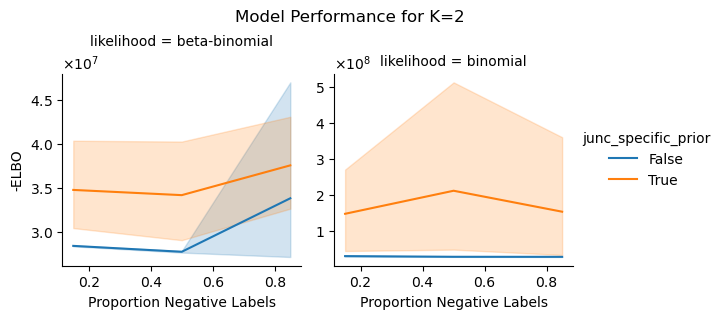

In [4]:
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(run_summary_K2, 
                  col="likelihood",
                  hue="junc_specific_prior",
                  sharey=False)

# Use line plot to show trends more clearly
g.map(sns.lineplot, "proportion_negative", "best_elbo")

# Format y-axis labels
for ax in g.axes.flat:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

g.add_legend()
g.set_axis_labels("Proportion Negative Labels", "-ELBO")

g.fig.suptitle('Model Performance for K=2', y=1.05)  # y=1.02 raises it slightly above the plots

Text(0.5, 1.05, 'Model Performance for K=2')

<Figure size 1200x600 with 0 Axes>

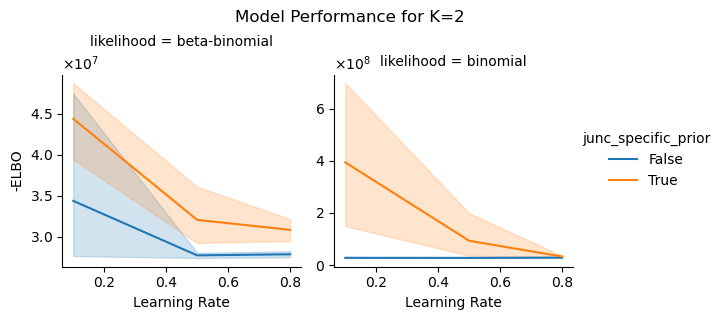

In [5]:
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(run_summary_K2, 
                  col="likelihood",
                  hue="junc_specific_prior",
                  sharey=False)

# Use line plot to show trends more clearly
g.map(sns.lineplot, "lr", "best_elbo")

# Format y-axis labels
for ax in g.axes.flat:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

g.add_legend()
g.set_axis_labels("Learning Rate", "-ELBO")

# Add title
g.fig.suptitle('Model Performance for K=2', y=1.05)  # y=1.02 raises it slightly above the plots

In [6]:
run_summary_K2[run_summary_K2["likelihood"] == "binomial"].sort_values(by=["junc_specific_prior", "best_elbo"])


,param_id,K,junc_specific_prior,best_elbo,input_conc,num_epochs,num_inits,cell_type_silhouette,avg_corr,median_corr,...,spearman_corr_impdfiff,pearson_corr_impdiff,proportion_negative,pruned_K,likelihood,auc_pr,auc_roc,pearson_corr_es,spearman_corr_es,run
26,177,2,False,2.660305e+07,inf,300,5,0.941710,0.509303,0.846015,...,0.617978,0.999769,0.85,2,binomial,0.828126,0.958124,0.763931,0.539953,run_177
7,168,2,False,2.709291e+07,inf,300,5,0.935711,0.141417,0.020522,...,0.620225,0.999788,0.85,2,binomial,0.946898,0.938838,0.999691,0.619468,run_168
35,178,2,False,2.716152e+07,inf,300,5,0.944460,0.999736,0.999768,...,0.619485,0.999806,0.85,2,binomial,0.940070,0.930734,0.996718,0.607320,run_178
25,188,2,False,2.721787e+07,inf,300,5,0.926263,0.371337,0.041785,...,0.610696,0.997622,0.85,2,binomial,0.920937,0.983818,0.710420,0.545491,run_188
62,170,2,False,2.727365e+07,inf,300,5,0.939828,0.205628,0.064574,...,0.619107,0.999823,0.85,2,binomial,0.948580,0.940724,0.999720,0.616871,run_170
80,163,2,False,2.727792e+07,inf,300,5,0.963718,0.997782,0.998086,...,0.934656,0.999905,0.50,2,binomial,0.977892,0.969620,0.915999,0.872119,run_163
5,179,2,False,2.730060e+07,inf,300,5,0.940124,0.583938,0.867514,...,0.619324,0.999773,0.85,2,binomial,0.373852,0.651656,0.155406,0.138263,run_179
30,171,2,False,2.750563e+07,inf,300,5,0.964523,0.664552,0.994279,...,0.932972,0.999879,0.50,2,binomial,0.962037,0.931326,0.999739,0.932729,run_171
61,181,2,False,2.752931e+07,inf,300,5,0.963768,0.632740,0.985338,...,0.932187,0.999581,0.50,2,binomial,0.960399,0.928005,0.997746,0.925680,run_181
29,182,2,False,2.754381e+07,inf,300,5,0.963063,0.585762,0.995465,...,0.931046,0.999684,0.50,2,binomial,0.978080,0.963713,0.980759,0.914177,run_182


Text(0.5, 1.05, 'Model Performance for K=9')

<Figure size 1200x600 with 0 Axes>

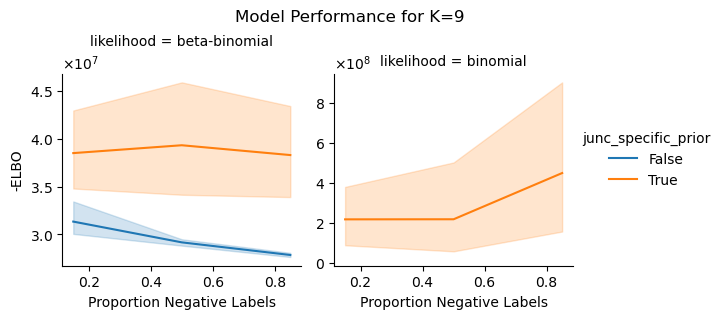

In [7]:
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(run_summary_K9, 
                  col="likelihood",
                  hue="junc_specific_prior",
                  sharey=False)

# Use line plot to show trends more clearly
g.map(sns.lineplot, "proportion_negative", "best_elbo")

# Format y-axis labels
for ax in g.axes.flat:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

g.add_legend()
g.set_axis_labels("Proportion Negative Labels", "-ELBO")

g.fig.suptitle('Model Performance for K=9', y=1.05)  # y=1.02 raises it slightly above the plots

Text(0.5, 1.05, 'Model Performance for K=9')

<Figure size 1200x600 with 0 Axes>

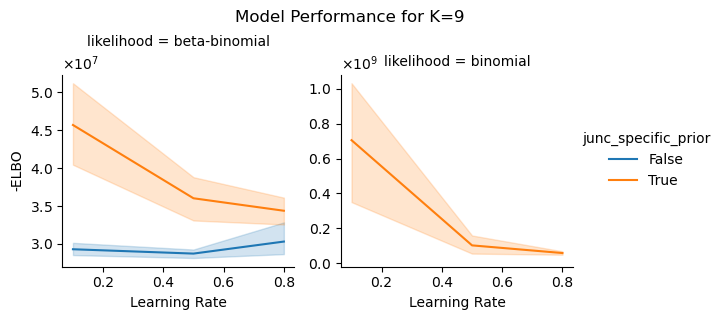

In [8]:
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(run_summary_K9, 
                  col="likelihood",
                  hue="junc_specific_prior",
                  sharey=False)

# Use line plot to show trends more clearly
g.map(sns.lineplot, "lr", "best_elbo")

# Format y-axis labels
for ax in g.axes.flat:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)

g.add_legend()
g.set_axis_labels("Learning Rate", "-ELBO")

# Add title
g.fig.suptitle('Model Performance for K=9', y=1.05)  # y=1.02 raises it slightly above the plots

### Now let's summarize accuracy metrics 

<Figure size 1000x600 with 0 Axes>

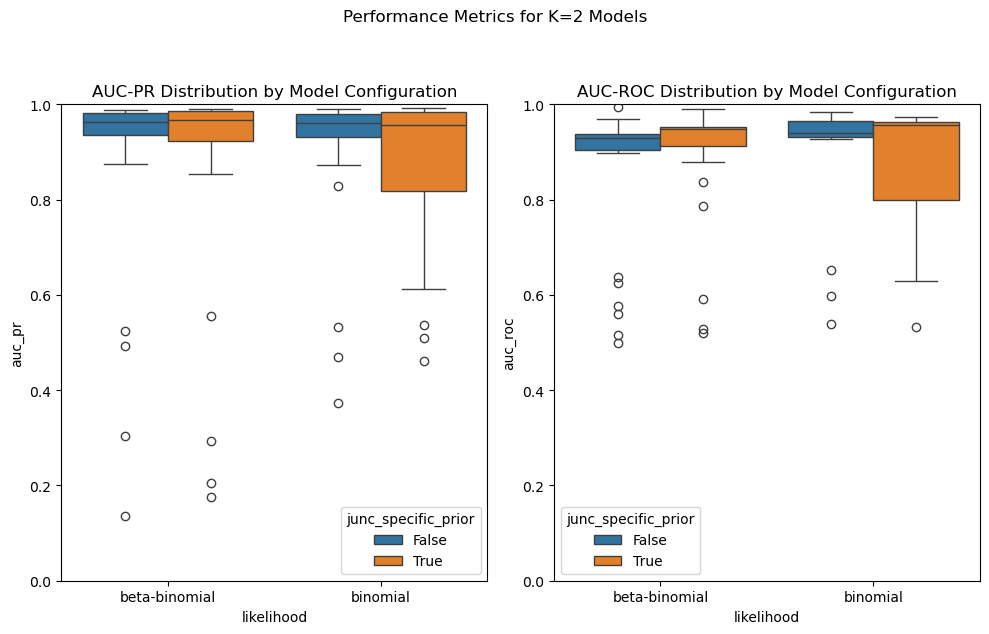

In [9]:
plt.figure(figsize=(10, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Plot for AUC-PR
sns.boxplot(x='likelihood', y='auc_pr', 
           hue='junc_specific_prior',
           data=run_summary_K2, ax=ax1)
ax1.set_title('AUC-PR Distribution by Model Configuration')
ax1.set_ylim(0, 1)

# Plot for AUC-ROC
sns.boxplot(x='likelihood', y='auc_roc',
           hue='junc_specific_prior',
           data=run_summary_K2, ax=ax2)
ax2.set_title('AUC-ROC Distribution by Model Configuration')
ax2.set_ylim(0, 1)

plt.suptitle('Performance Metrics for K=2 Models', y=1.05)
plt.tight_layout()

<Figure size 1000x600 with 0 Axes>

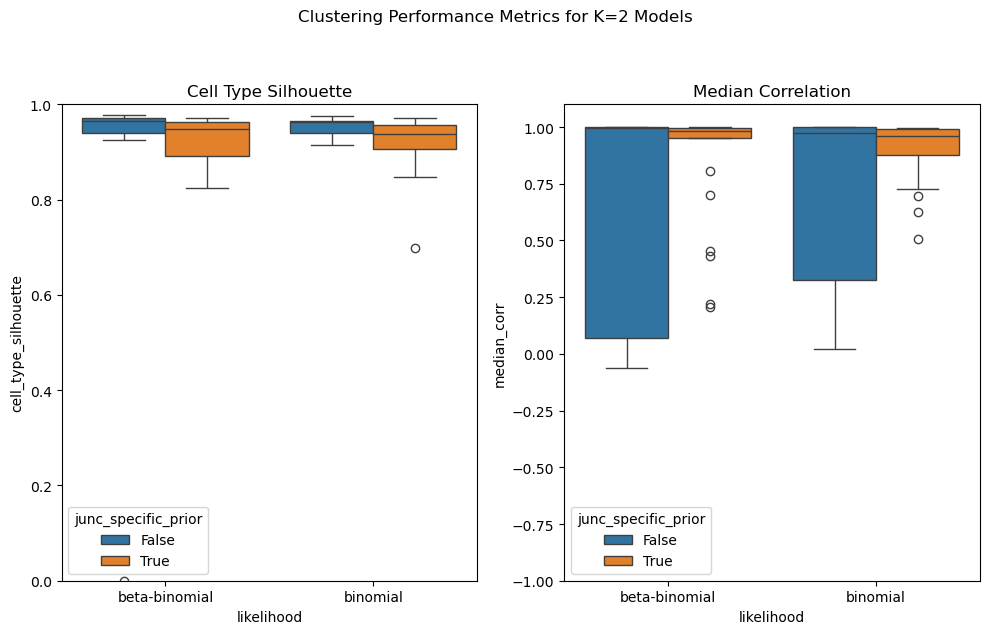

In [10]:
# Second figure for Silhouette and Correlation metrics
plt.figure(figsize=(10, 6))
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(10, 6))

# Plot for Cell Type Silhouette
sns.boxplot(x='likelihood', y='cell_type_silhouette',
            hue='junc_specific_prior',
            data=run_summary_K2, ax=ax3)
ax3.set_title('Cell Type Silhouette')
ax3.set_ylim(0, 1)

# Plot for Median Correlation
sns.boxplot(x='likelihood', y='median_corr',
            hue='junc_specific_prior',
            data=run_summary_K2, ax=ax4)
ax4.set_title('Median Correlation')
ax4.set_ylim(-1, 1.1)  # Since correlation ranges from -1 to 1

plt.suptitle('Clustering Performance Metrics for K=2 Models', y=1.05)
plt.tight_layout()